## Modelos de Classificação e Regressão Logística
# Desafio Final

---

##dataset = iris

In [ ]:
#Bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

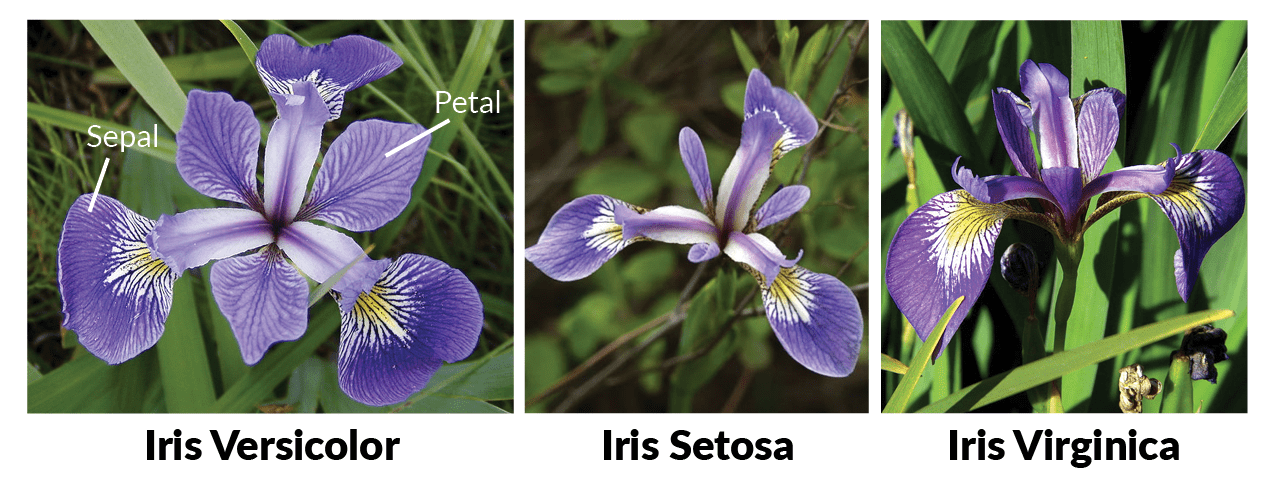

### Analise Exploratória (EDA)

In [ ]:
#carregando iris dataset
iris = datasets.load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
# carregando a variavel target ()
df_iris['iris_id'] = iris.target
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
# Selecionando uma amostra dos dados
df_iris.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_id,species
70,5.9,3.2,4.8,1.8,1,versicolor
57,4.9,2.4,3.3,1.0,1,versicolor
22,4.6,3.6,1.0,0.2,0,setosa
51,6.4,3.2,4.5,1.5,1,versicolor
126,6.2,2.8,4.8,1.8,2,virginica
12,4.8,3.0,1.4,0.1,0,setosa
44,5.1,3.8,1.9,0.4,0,setosa
97,6.2,2.9,4.3,1.3,1,versicolor
90,5.5,2.6,4.4,1.2,1,versicolor
74,6.4,2.9,4.3,1.3,1,versicolor


In [ ]:
# Quantidade de resgistros para cada espécie
df_iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
print(f"O dataset possui {df_iris.shape[0]} linhas e {df_iris.shape[1]} colunas ")

O dataset possui 150 linhas e 6 colunas 


In [ ]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   iris_id            150 non-null    int64   
 5   species            150 non-null    category
dtypes: category(1), float64(4), int64(1)
memory usage: 6.3 KB


In [ ]:
#identificando valores nulos e valores que não se repetem
datadict = pd.DataFrame(df_iris.dtypes)
datadict.columns = ["Dtype"]
datadict['Valores_Nulos'] = df_iris.isnull().sum()
datadict['%_Valores_Nulos'] = (df_iris.isnull().sum() / df_iris.shape[0]) * 100
datadict['NUnique']=df_iris.nunique()
print(datadict)

                      Dtype  Valores_Nulos  %_Valores_Nulos  NUnique
sepal length (cm)   float64              0              0.0       35
sepal width (cm)    float64              0              0.0       23
petal length (cm)   float64              0              0.0       43
petal width (cm)    float64              0              0.0       22
iris_id               int64              0              0.0        3
species            category              0              0.0        3




---

### Boxplot e o histograma para caracterizar as propriedades de cada uma das espécies existentes.

<ipython-input-8-fd960d7bbdfb>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_iris, x = 'species', y = col, ax = axes[i], palette = 'RdPu')
<ipython-input-8-fd960d7bbdfb>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_iris, x = 'species', y = col, ax = axes[i], palette = 'RdPu')
<ipython-input-8-fd960d7bbdfb>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_iris, x = 'species', y = col, ax = axes[i], palette = 'RdPu')
<ipython-input-8-fd960d7bbdfb>:6: FutureWarning: 

Passing `palette` without assigning `hue

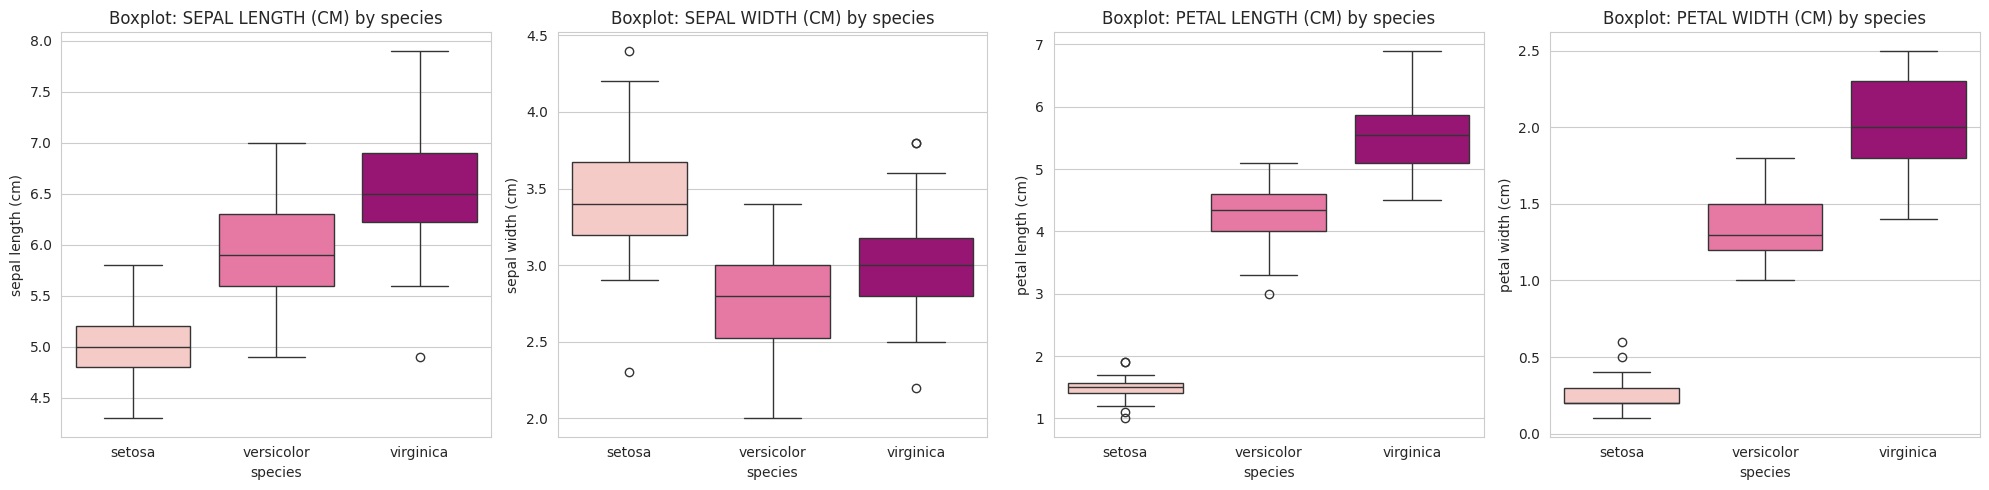

In [ ]:
# Boxplot
columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 4, figsize = (20, 5))
for i, col in enumerate (columns):
  sns.boxplot(data = df_iris, x = 'species', y = col, ax = axes[i], palette = 'RdPu')
  axes[i].set_title(f'Boxplot: {col.upper()} by species')
plt.tight_layout()
plt.show()

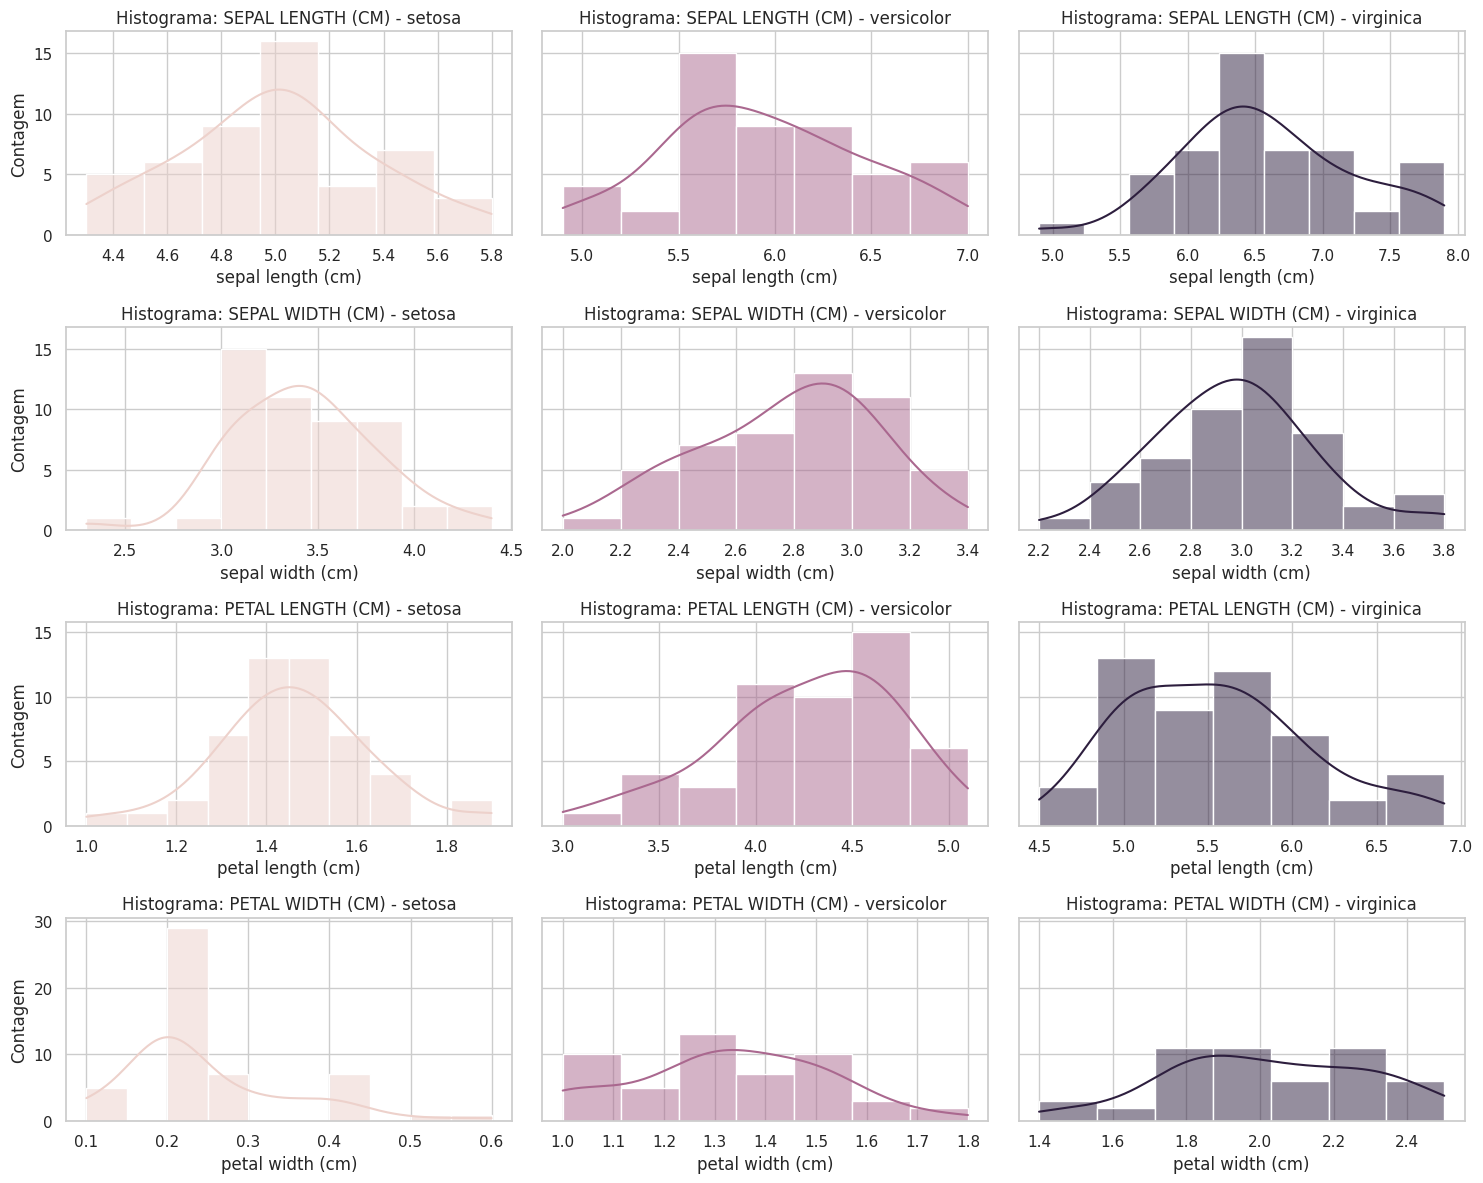

In [ ]:
unique_val = df_iris['species'].unique()

sns.set(style="whitegrid")
cubehelix = sns.cubehelix_palette(n_colors=3)

# Criar figura com 4 linhas (1 por coluna), 3 colunas (1 por espécie)
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharey= 'row')

for i, col in enumerate(columns):
    for j, species in enumerate(unique_val):
        df_species = df_iris[df_iris['species'] == species]

        sns.histplot(df_species[col], kde=True, ax=axes[i, j], color=cubehelix[j])
        axes[i, j].set_title(f'Histograma: {col.upper()} - {species}')
        axes[i, j].set_xlabel(col)
        axes[i, j].set_ylabel('Contagem')

plt.tight_layout()
plt.show()

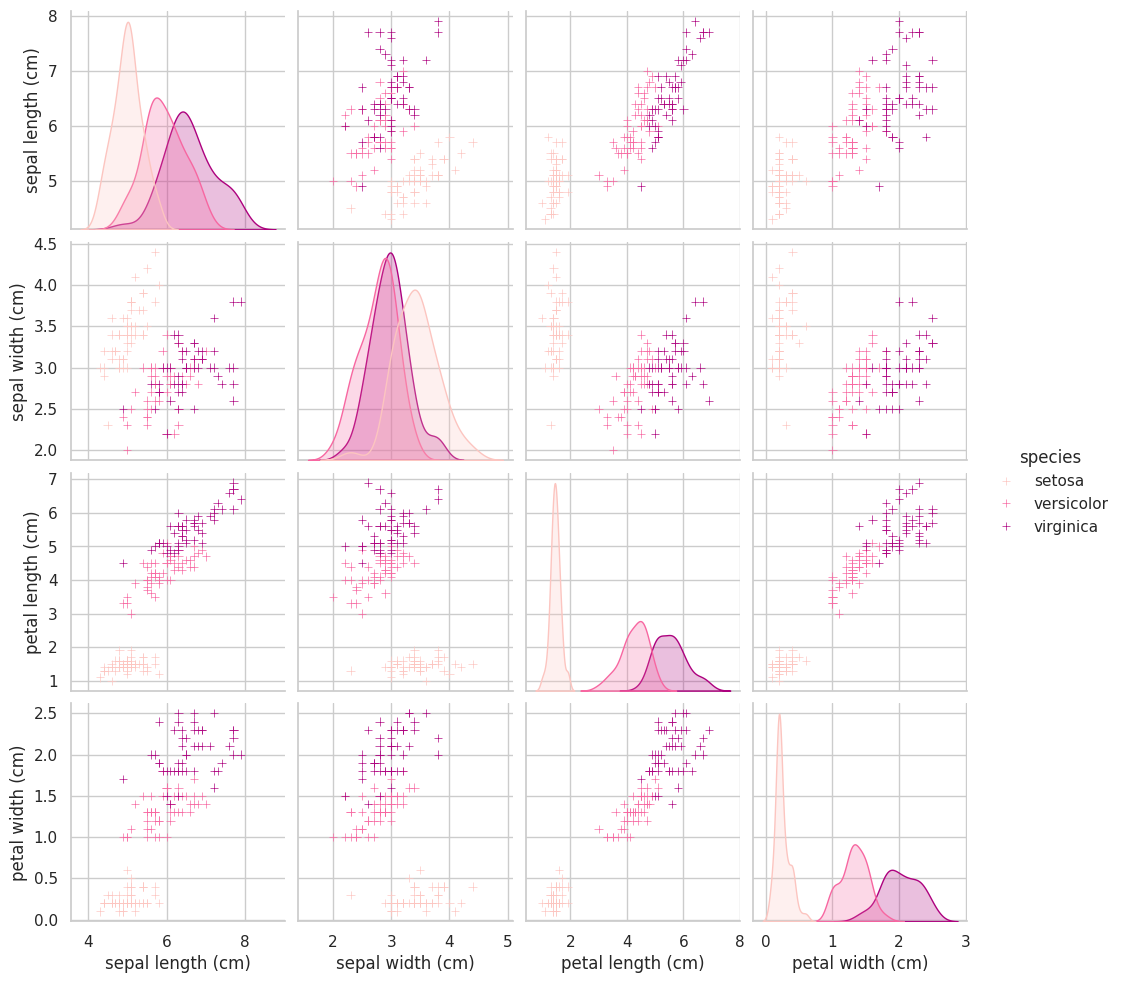

In [ ]:
tmp = df_iris.drop('iris_id', axis=1)
g = sns.pairplot(tmp, hue='species', markers='+', palette = 'RdPu')
plt.show()



---

### Analise da distinção entre as espécies


**Conclusão**:

Com base nos gráficos de boxplot, histogramas por espécie e no pairplot com coloração por espécie, foi possível observar que as variáveis do conjunto de dados Iris apresentam diferentes níveis de capacidade discriminativa entre as três espécies: setosa, versicolor e virginica.

As variáveis `petal length (cm)` e `petal width (cm)` se mostraram altamente informativas, especialmente para distinguir a espécie setosa, que possui valores nitidamente menores nessas dimensões. Já as espécies versicolor e virginica apresentaram certa sobreposição nesses atributos, mas ainda com tendências distintas de distribuição, visíveis nas medianas e nos formatos das curvas de densidade.

As variáveis `sepal length (cm)` e `sepal width (cm)`, por outro lado, demonstraram menor poder discriminatório, pois seus valores se sobrepõem mais entre as espécies.

O pairplot reforçou essas observações ao mostrar que setosa forma um grupo bem separado no espaço das variáveis, enquanto versicolor e virginica se sobrepõem parcialmente, mas com possíveis fronteiras de decisão em alguns pares de atributos.

De modo geral, a análise gráfica sugere que é viável distinguir as espécies com base nas variáveis disponíveis, com maior precisão para setosa e moderada distinção entre versicolor e virginica.



---



### Avaliando Modelo de regressão de classificação com regressão logistica

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#x -> variaveis explicativas
X = df_iris[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
# y -> variavel target
y = df_iris['species']

# Separar os dados em conjuntos de treinamento (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Inicializar e treinar o modelo de Regressão Logística
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

# Previsões
y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled) # Probabilities for each class

# Create a DataFrame for test results
X_test_results = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_results['Actual_species'] = y_test.reset_index(drop=True)
X_test_results['Predicted_species'] = y_pred

# Add probability columns for each class
for i, species in enumerate(logreg.classes_):
    X_test_results[f'Probability_{species}'] = y_pred_proba[:, i]

#resultados
print('Acurácia:', accuracy_score(y_test, y_pred))
print('\nMatriz de Confusão:\n')
print(confusion_matrix(y_test, y_pred))
print('\nRelatório de Classificação:\n')
print(classification_report(y_test, y_pred))

# Display the test results DataFrame
print('\nTest Results with Predictions and Probabilities:\n')
display(X_test_results.head())

Acurácia: 0.9333333333333333

Matriz de Confusão:

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Relatório de Classificação:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Test Results with Predictions and Probabilities:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Actual_species,Predicted_species,Probability_setosa,Probability_versicolor,Probability_virginica
0,-1.721568,-0.108213,-1.402504,-1.323276,setosa,setosa,0.978818,0.021182,3.638218e-07
1,0.308489,-0.108213,0.641631,0.783432,virginica,virginica,0.003798,0.369220,6.269815e-01
2,-1.124492,-1.451543,-0.266873,-0.269922,versicolor,versicolor,0.148799,0.842475,8.726064e-03
3,-1.005077,-1.675431,-0.266873,-0.269922,versicolor,versicolor,0.095445,0.894619,9.936370e-03
4,-1.721568,0.339564,-1.402504,-1.323276,setosa,setosa,0.988493,0.011507,1.725496e-07


###Matriz de confusão

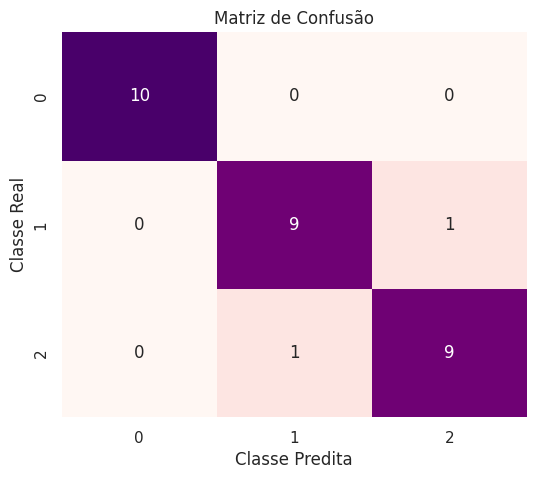

In [ ]:
#plotando a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='RdPu', fmt='g', cbar=False)
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show()



---

## Dataset = Digits

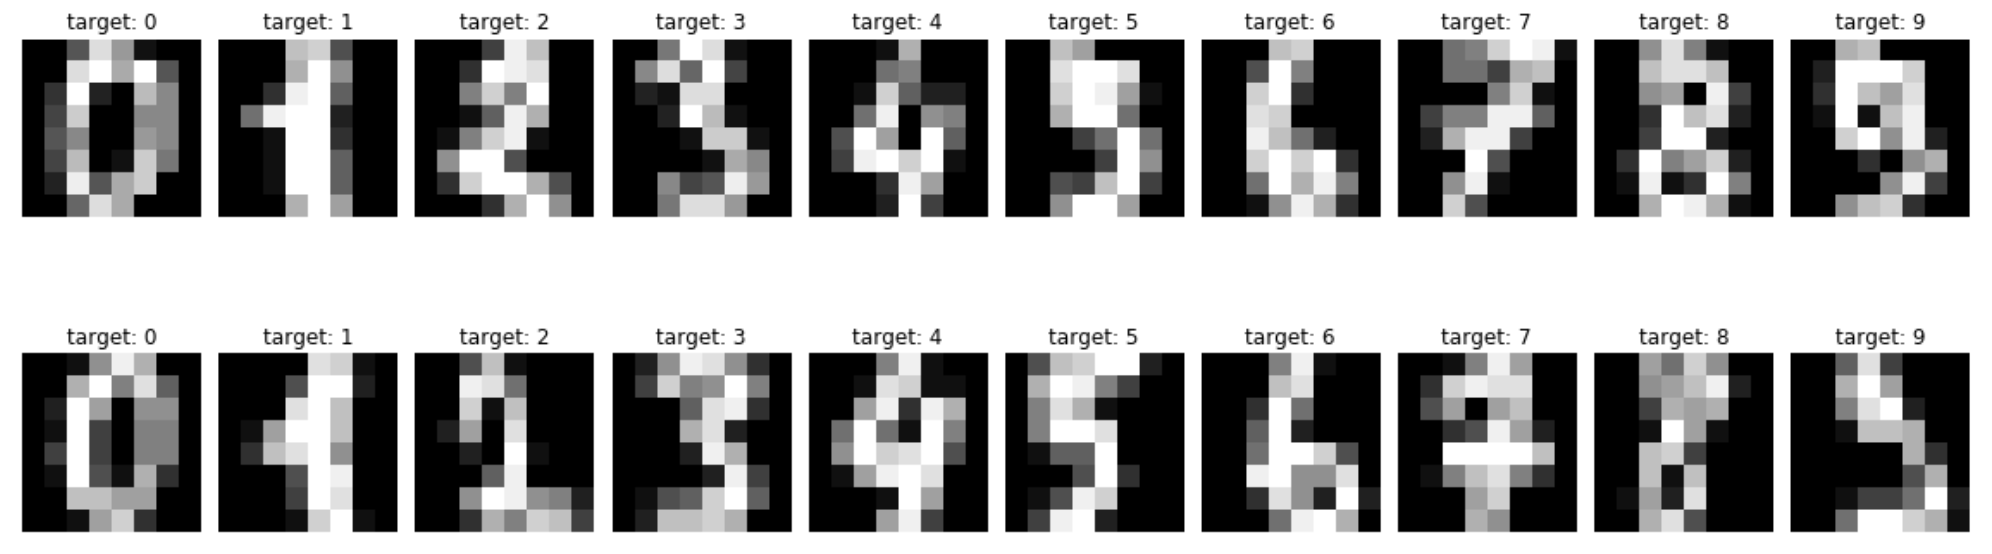

In [ ]:
# carregando dataset
digits = datasets.load_digits()
df_digits = pd.DataFrame(digits.data, columns=digits.feature_names)
# variavel target
df_digits['target'] = digits.target
# amostra do dataset
df_digits.sample(10)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
892,0.0,0.0,10.0,15.0,13.0,1.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,10.0,16.0,12.0,3.0,0.0,0.0,2
746,0.0,0.0,1.0,14.0,8.0,8.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,4
316,0.0,0.0,7.0,14.0,16.0,11.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,6.0,16.0,12.0,5.0,0.0,0.0,3
591,0.0,0.0,7.0,15.0,13.0,0.0,0.0,0.0,0.0,9.0,...,7.0,0.0,0.0,5.0,16.0,14.0,12.0,12.0,11.0,2
361,0.0,0.0,3.0,11.0,15.0,13.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,16.0,1.0,0.0,0.0,0.0,9
156,0.0,0.0,0.0,16.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,11.0,16.0,15.0,9.0,0.0,6
1741,0.0,0.0,3.0,10.0,16.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,13.0,10.0,1.0,0.0,0.0,5
1532,0.0,0.0,15.0,14.0,15.0,9.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,10.0,16.0,15.0,4.0,0.0,0.0,5
599,0.0,0.0,1.0,7.0,12.0,3.0,0.0,0.0,0.0,4.0,...,5.0,0.0,0.0,1.0,9.0,15.0,16.0,16.0,8.0,3
16,0.0,0.0,0.0,8.0,15.0,1.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,7.0,15.0,16.0,11.0,0.0,6


### Analise inicial (EDA)

In [ ]:
# Verificando quantos registros possui o dataset
print(f"O dataset possui {df_digits.shape[0]} linhas e {df_digits.shape[1]} colunas ")

O dataset possui 1797 linhas e 65 colunas 


In [ ]:
#identificando valores nulos e valores que não se repetem
datadict = pd.DataFrame(df_digits.dtypes)
datadict.columns = ["Dtype"]
datadict['Valores_Nulos'] = df_digits.isnull().sum()
datadict['%_Valores_Nulos'] = (df_digits.isnull().sum() / df_digits.shape[0]) * 100
datadict['NUnique']=df_digits.nunique()
print(datadict)

             Dtype  Valores_Nulos  %_Valores_Nulos  NUnique
pixel_0_0  float64              0              0.0        1
pixel_0_1  float64              0              0.0        9
pixel_0_2  float64              0              0.0       17
pixel_0_3  float64              0              0.0       17
pixel_0_4  float64              0              0.0       17
...            ...            ...              ...      ...
pixel_7_4  float64              0              0.0       17
pixel_7_5  float64              0              0.0       17
pixel_7_6  float64              0              0.0       17
pixel_7_7  float64              0              0.0       17
target       int64              0              0.0       10

[65 rows x 4 columns]


In [ ]:
df_digits.info()
print('O dataset possui apenas variaveis numéricas')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

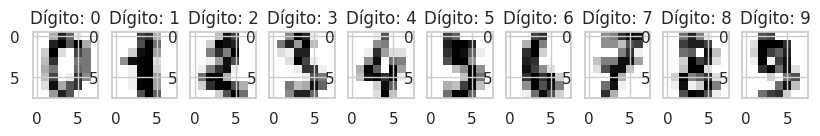

In [ ]:
#Plotando os digitos
fig, axes = plt.subplots(1, 10, figsize = (10, 14))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.set_title(f'Dígito: {i}')

In [ ]:
# aplicando regressão logistica  no modelo
X = df_digits.drop('target', axis=1)
y = df_digits['target']

# Seprando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Inicializar e treinar o modelo de Regressão Logística
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

# Previsões
y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled)

#resultados
print('Acurácia:', accuracy_score(y_test, y_pred))
print('\nMatriz de Confusão:\n')
print(confusion_matrix(y_test, y_pred))
print('\nRelatório de Classificação:\n')
print(classification_report(y_test, y_pred))

# Display the test results DataFrame
print('\nTest Results with Predictions and Probabilities:\n')
display(X_test_results.head())

Acurácia: 0.9722222222222222

Matriz de Confusão:

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  1  1  0  0  0  2  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  4  0  0  0  0  0  0 31  0]
 [ 0  0  0  0  0  0  0  0  1 35]]

Relatório de Classificação:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99    

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Actual_species,Predicted_species,Probability_setosa,Probability_versicolor,Probability_virginica
0,-1.721568,-0.108213,-1.402504,-1.323276,setosa,setosa,0.978818,0.021182,3.638218e-07
1,0.308489,-0.108213,0.641631,0.783432,virginica,virginica,0.003798,0.369220,6.269815e-01
2,-1.124492,-1.451543,-0.266873,-0.269922,versicolor,versicolor,0.148799,0.842475,8.726064e-03
3,-1.005077,-1.675431,-0.266873,-0.269922,versicolor,versicolor,0.095445,0.894619,9.936370e-03
4,-1.721568,0.339564,-1.402504,-1.323276,setosa,setosa,0.988493,0.011507,1.725496e-07


###Matriz de confusão

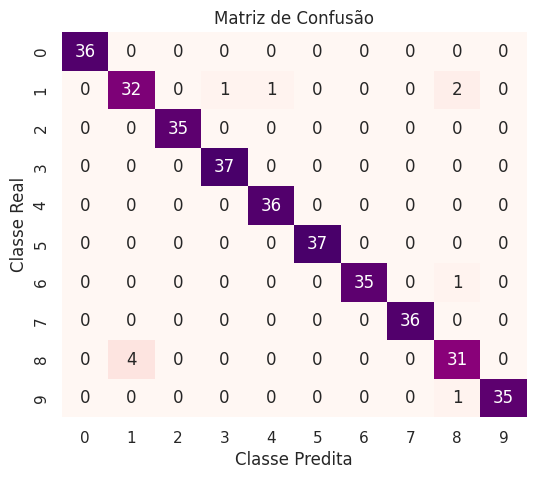

In [ ]:
#plotando a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='RdPu', fmt='g', cbar=False)
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show()